In [43]:
import pandas as pd, numpy as np, os, sys, warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Fit Frenchie Data Overview

## Datasets

### 1. `fit_frenchie_trades`
Trade history for the last 10 days (since the mint). This dataset contains 2000 rows with the following columns:
- `nft_id`: Index of the Fit Frenchie sold
- `trade_price`: Price sold
- `floor_price`: Current lowest offer (to sell) for any Fit Frenchie at the time of the trade

### 2. `fit_frenchie_attributes`
The full collection metadata, which maps each `nft_id` to attribute values. 

For example, the `Background` for Fit Frenchie #1046 is `Lavender Dusk Purple`. This dataset contains the following columns:
- `nft_id`: Index of the Fit Frenchie (matches the `nft_id` found in `fit_frenchie_trades`)
- `Accessories`: Attribute or trait of the given Fit Frenchie
- `Background`: Attribute or trait of the given Fit Frenchie
- `Body`: Attribute or trait of the given Fit Frenchie
- `Eyes`: Attribute or trait of the given Fit Frenchie
- `Hat`: Attribute or trait of the given Fit Frenchie
- `Mouth`: Attribute or trait of the given Fit Frenchie

For each attribute, there are 10-22 possible values.

In [50]:
attributes = pd.read_csv('data/fit_frenchie_attributes.csv')
attributes = attributes.astype(str)
attributes['nft_id'] = attributes['nft_id'].astype(int)

trades = pd.read_csv('data/fit_frenchie_trades.csv')
trades = trades.astype(float)
trades['nft_id'] = trades['nft_id'].astype(int)
    
# merge attributes on trades using nft_id

df = pd.merge(trades, attributes, on='nft_id', how='inner')

features = ['Accessories', 'Background', 'Body', 'Eyes', 'Hat', 'Mouth']
# for col in features:
#     df[col] = df[col].astype(str)
    
df

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth
0,1088,4.00,4.00,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
1,1088,5.16,5.16,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
2,1088,8.15,8.15,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
3,1088,4.14,4.14,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad
4,1065,4.00,4.00,None,Spiced Orange,Tan,White Shades,Headphones,Toothy
...,...,...,...,...,...,...,...,...,...
1995,36,1.51,0.95,Wings,Lavender Dusk Purple,Tan,Laser Eyes,No Hat,Sad
1996,1028,0.94,0.94,Red Bandana,Forest Moss Green,Black - Overweight,Red Round Shades,Cylinder,Toothy
1997,59,0.94,0.94,None,Sunlit Gold,Tan,Drowsy,Party Hat,Drooling
1998,614,0.91,0.91,Neck Tattoo,Lavender Dusk Purple,Black,White Round Shades,Slickback,Toothy


In [ ]:
# note any observations you have for each data set. Are some attributes rarer than others? 

# What hypotheses do you have for the relationship between `trade_price` and `floor_price`? What causes a Fit Frenchie to sell for more than the `floor_price` at the time?

# **Build a model for predicting the price of Fit Frenchies. What should Hunter list Fit Frenchie #1046 for?**

In [51]:
df[df['nft_id'] == 1046] # 1046 never got traded

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth


In [63]:
attributes_1046 = attributes[attributes['nft_id'] == 1046].astype(str).to_dict(orient='records')[0]
attributes_1046

{'nft_id': '1046',
 'Accessories': 'Samurai Sword',
 'Background': 'Lavender Dusk Purple',
 'Body': 'Tan',
 'Eyes': '3-D Glasses',
 'Hat': 'Beret',
 'Mouth': 'Surprised'}

In [8]:
attributes

,nft_id,Accessories,Background,Body,Eyes,Hat,Mouth
0,0,Neck Tattoo,Lavender Dusk Purple,Cream,Normal,Slickback,Sad
1,1,Scarf,Spiced Orange,Cream,Normal,Dreads,Drooling
2,2,None,Seashell Pink,Black,Normal,Elvis,Sad
3,3,Red Bandana,Forest Moss Green,White,Concerned,Headband,Bubble Gum
4,4,Scarf,Sunlit Gold,Black,White Shades,No Hat,Surprised
...,...,...,...,...,...,...,...
1495,1495,None,Stormcloud Grey,Black - Overweight,Normal,No Hat,Mustache
1496,1496,Bow Tie,Lavender Dusk Purple,Blue,Red Shades,Fire,Feral
1497,1497,None,Forest Moss Green,Cream,Red Shades,No Hat,Happy
1498,1498,Bow Tie,Rose Quartz Pink,Black - Overweight,Red Shades,Sobrero,Toothy


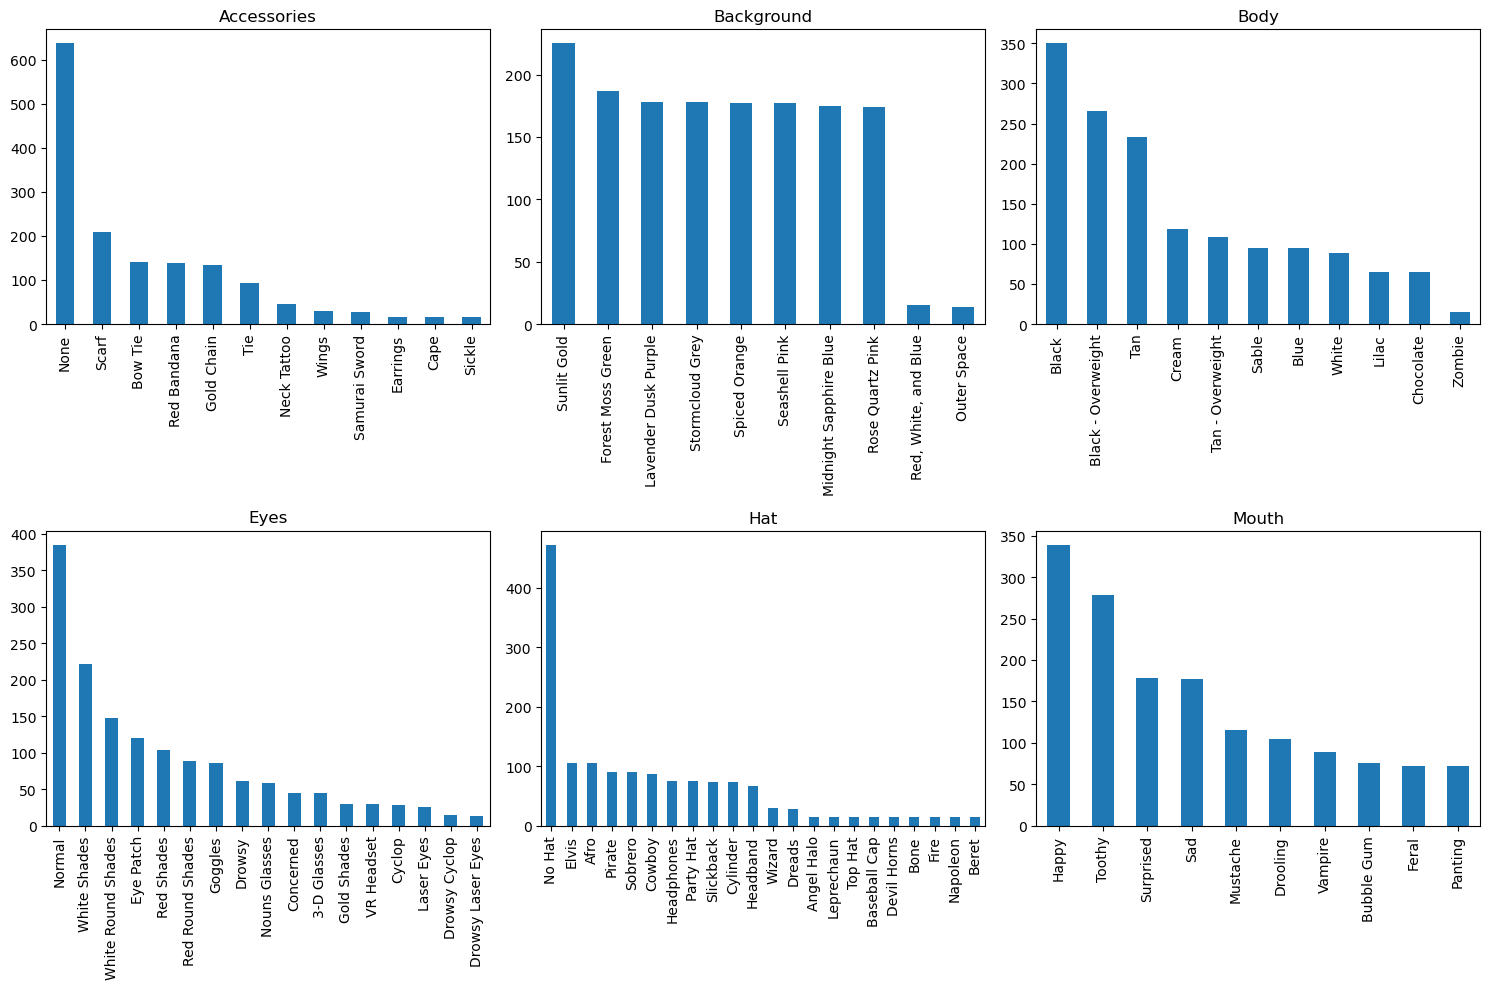

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), features):
    attributes[feature].value_counts().plot(kind='bar', ax=ax, title=feature)

plt.tight_layout()
plt.show()

In [68]:
normalized_freq_dict = {}

for feature in features:
    value_counts = attributes[feature].value_counts(normalize=True).round(4)
    normalized_freq_dict[feature] = value_counts.to_dict()

normalized_freq_dict

{'Accessories': {'None': 0.4247,
  'Scarf': 0.1393,
  'Bow Tie': 0.0933,
  'Red Bandana': 0.092,
  'Gold Chain': 0.09,
  'Tie': 0.0627,
  'Neck Tattoo': 0.03,
  'Wings': 0.0193,
  'Samurai Sword': 0.0187,
  'Earrings': 0.01,
  'Cape': 0.01,
  'Sickle': 0.01},
 'Background': {'Sunlit Gold': 0.15,
  'Forest Moss Green': 0.1247,
  'Lavender Dusk Purple': 0.1187,
  'Stormcloud Grey': 0.1187,
  'Spiced Orange': 0.118,
  'Seashell Pink': 0.118,
  'Midnight Sapphire Blue': 0.1167,
  'Rose Quartz Pink': 0.116,
  'Red, White, and Blue': 0.01,
  'Outer Space': 0.0093},
 'Body': {'Black': 0.2333,
  'Black - Overweight': 0.1773,
  'Tan': 0.1553,
  'Cream': 0.0787,
  'Tan - Overweight': 0.0727,
  'Sable': 0.0633,
  'Blue': 0.0633,
  'White': 0.0593,
  'Lilac': 0.0433,
  'Chocolate': 0.0433,
  'Zombie': 0.01},
 'Eyes': {'Normal': 0.2567,
  'White Shades': 0.148,
  'White Round Shades': 0.0987,
  'Eye Patch': 0.08,
  'Red Shades': 0.0687,
  'Red Round Shades': 0.0587,
  'Goggles': 0.0573,
  'Drowsy':

In [69]:
attributes_1046

{'nft_id': '1046',
 'Accessories': 'Samurai Sword',
 'Background': 'Lavender Dusk Purple',
 'Body': 'Tan',
 'Eyes': '3-D Glasses',
 'Hat': 'Beret',
 'Mouth': 'Surprised'}

In [70]:
frequency_rate_1046 = {feature: normalized_freq_dict[feature].get(attributes_1046[feature], 0) for feature in features}
frequency_rate_1046

{'Accessories': 0.0187,
 'Background': 0.1187,
 'Body': 0.1553,
 'Eyes': 0.0293,
 'Hat': 0.0093,
 'Mouth': 0.1187}

In [30]:
# correlation between trade_price and floor_price
correlation_floor_trade = trades.corr()['floor_price']['trade_price']
print(f'Correlation between trade_price and floor_price: {correlation_floor_trade:.2%}')

Correlation between trade_price and floor_price: 53.41%


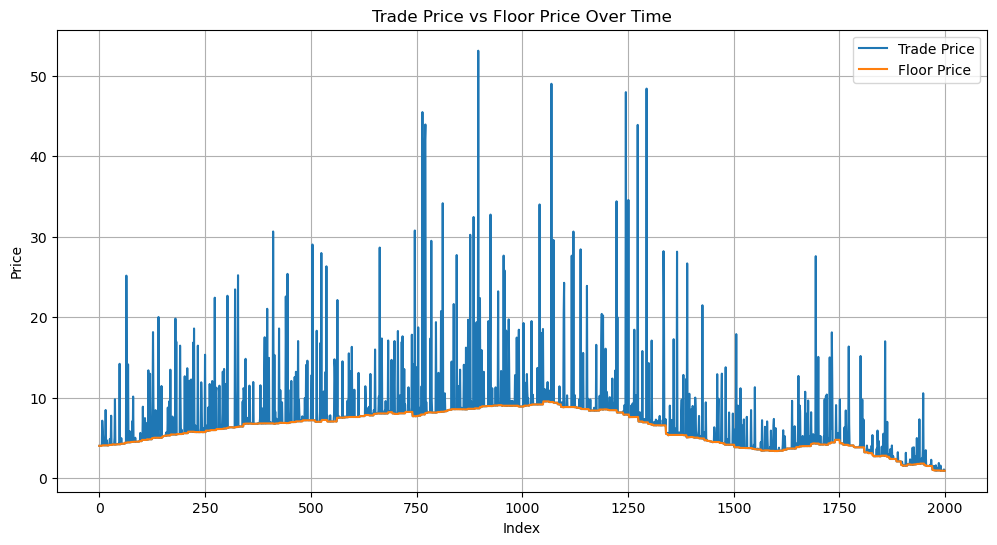

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(trades['trade_price'], label='Trade Price')
plt.plot(trades['floor_price'], label='Floor Price')

plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Trade Price vs Floor Price Over Time')
plt.legend()
plt.grid(True)

plt.show()

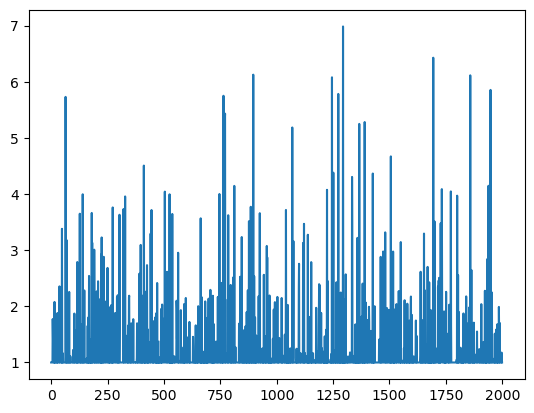

In [74]:
(trades['trade_price']/trades['floor_price']).plot()
plt.show()

In [ ]:
# for the model we hqve two things to consider:
# 1. the attributes of the frenchie
# 2. the floor price of the frenchie

# To price the features we can use past data of the frechies that were sold 
# by detrending the trade price from the floor price to remove the effect coming from the market demand
# then we will be able to price frecnhies amoung them purely based on the attributes
# after adjusting (multiplying by the floor price) we are able to get the price for any nft

# we can use a linear regression model to predict the trade price of a frenchie
# we can use the attributes of the frenchie as features and the floor price as the target variable

In [ ]:
# an other model is just to take a tree model and use features as categorical variables to predict the trade price

In [71]:
# for the price prediction model, we can use a linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[features]
y = df['trade_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error: {rmse:.2f}')


ValueError: could not convert string to float: 'Tie'